In [58]:
# Importing the necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.integrate
import numpy.polynomial.legendre

## Part 1 - Gauss Legendre

In [59]:
# Result using inbuilt integration
def f(x):
    return 1.0/np.sqrt(1 + x**2)

a = 0
b = 5

result, error = scipy.integrate.quad(f, a, b)

print("The Integral is = ", result)
print("The error in calculation = ", error)

The Integral is =  2.3124383412727525
The error in calculation =  8.039113835999995e-10


In [60]:
# Limits of integration
a = 0
b = 5

# number of quadrature points
n = 5

# Weights(w) and nodes(nd) for Gauss Legendre
x = numpy.polynomial.legendre.leggauss(n)[0]
w = numpy.polynomial.legendre.leggauss(n)[1]

result = 0.0

for i in range(n):
    # defining the transformed variable
    t = ((b - a) * x[i] + (a - b)) / 2.0
    result = result + w[i]*f(t)

result = result * (b - a) / 2.0

exact = 2.312438341272753
error = abs(result - exact)
print("The Integral = ", result)
print("The error in calculation is = ", error)

The Integral =  2.3112873414551993
The error in calculation is =  0.0011509998175536218


## Part 2 - Monte Carlo Integration

### graph from c++

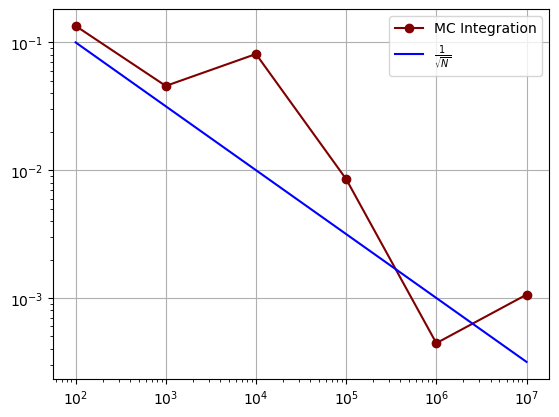

In [65]:
n = [100, 1000, 10000, 100000, 1000000, 10000000]
error = [0.134641, 0.0456392, 0.0810976, 0.00851934, 0.000443086, 0.001062]

plt.loglog(n, error, marker='o', color= 'maroon', label = 'MC Integration')
plt.loglog(n, 1/np.sqrt(n), 'blue', label = r"$\frac{1}{\sqrt{N}}$")
plt.grid(True)
plt.legend()


### Python code

╒══════════╤════════════╤═════════════╕
│        N │   Integral │       Error │
╞══════════╪════════════╪═════════════╡
│      100 │    4.31345 │ 0.43385     │
├──────────┼────────────┼─────────────┤
│     1000 │    3.86707 │ 0.0125237   │
├──────────┼────────────┼─────────────┤
│    10000 │    3.89076 │ 0.0111622   │
├──────────┼────────────┼─────────────┤
│   100000 │    3.89396 │ 0.0143658   │
├──────────┼────────────┼─────────────┤
│  1000000 │    3.88036 │ 0.000761298 │
├──────────┼────────────┼─────────────┤
│ 10000000 │    3.8797  │ 0.000106998 │
╘══════════╧════════════╧═════════════╛


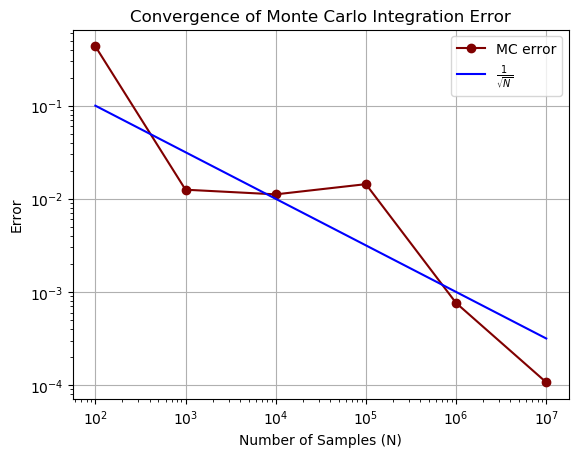

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

# Bounds of integration
a = -1
b = 10

E = []
exact = 3.8795965

# Number of samples
N = [100, 1000, 10000, 100000, 1000000, 10000000]

# MC integration implementation
I = []
for n in N:
    x = np.random.uniform(a, b, n)   # Generating uniform samples
    integral = (b - a) * np.mean([f(xi) for xi in x])   # Calculating function values and taking the average
    error = abs(integral - exact)
    I.append(integral)
    E.append(error)

# Print table of N, integral, and error
table = zip(N, I, E)
headers = ['N', 'Integral', 'Error']
print(tabulate(table, headers, tablefmt="fancy_grid"))

# Plotting the convergence of the error
plt.loglog(N, E, marker='o', color='maroon', label='MC error')
plt.loglog(N, 1/np.sqrt(N), color='blue', label=r'$\frac{1}{\sqrt{N}}$')
plt.xlabel('Number of Samples (N)')
plt.ylabel('Error')
plt.title('Convergence of Monte Carlo Integration Error')
plt.legend()
plt.grid(True)
plt.show()


## Part 3- Chebyshev polynomial

a[0]: 0.223606797749979
a[1]: 4.4408920985006264e-17
a[2]: 0.11180339887498947
a[3]: -4.4408920985006264e-17
a[4]: -0.11180339887498963


/tmp/ipykernel_588838/2778321654.py:26: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  f_approx = lambda x: np.sum(coefficients[i] * T[i](x) for i in range(n+1))


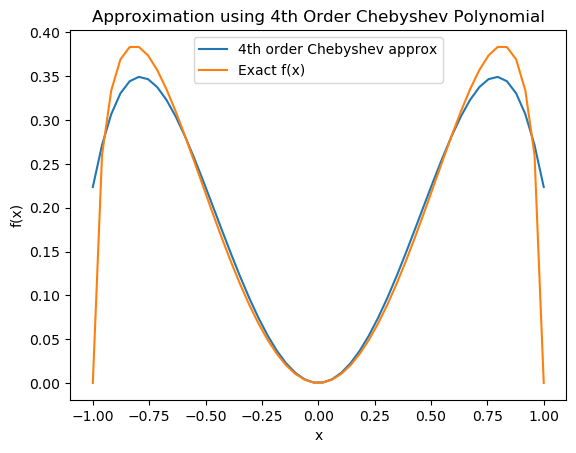

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

# Function to approximate
f = lambda x: x**2 * np.sqrt(1 - x**2)

# Domain [a, b]
a = -1
b = 1

# Polynomial order of approximation
n = 4

# Find the n+1 zeros of the (n+1)th-order Chebyshev polynomial
x = np.cos((2 * np.arange(n+1) + 1) * np.pi / (2 * (n+1)))

# Generate Chebyshev polynomials
T = [Chebyshev.basis(i) for i in range(n+1)]

# Compute n+1 coefficients
coefficients = [2 / (n+1) * np.sum(f(x) * T[i](x)) for i in range(n+1)]
coefficients[0] = 1 / (n+1) * np.sum(f(x))

# Reformat approximation as a lambda function
f_approx = lambda x: np.sum(coefficients[i] * T[i](x) for i in range(n+1))

# Print the coefficients
for i, coeff in enumerate(coefficients):
    print(f"a[{i}]: {coeff}")

# Plot resulting approximation
space = np.linspace(a, b)
plt.plot(space, f_approx(space), label="4th order Chebyshev approx")
plt.plot(space, f(space), label="Exact f(x)")
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Approximation using 4th Order Chebyshev Polynomial')
plt.show()
